*Вейвлет-визуализация сегментов ЭЭГ для детекции эпилептических приступов*

Этот код преобразует сигналы электроэнцефалограммы (ЭЭГ) в изображения с помощью непрерывного вейвлет-преобразования (CWT). Сегменты с приступами и нормальные сегменты сохраняются как изображения размером 64×64 пикселя для последующего обучения нейронной сети или классификатора.

In [ ]:
import os
import logging
from dataclasses import dataclass
from pathlib import Path
from typing import List, Tuple, Optional

import mne
import pywt
import numpy as np
from PIL import Image
from tqdm import tqdm

@dataclass(frozen=True)
class Config:
    """Конфигурация обработки ЭЭГ сигналов"""
    sample_rate: int = 256                          # Частота дискретизации (Гц)
    segment_duration: float = 5.0                   # Длина сегмента (секунды)
    image_size: Tuple[int, int] = (64, 64)          # Размер выходного изображения
    wavelet_overlap: float = 0.3                    # Перекрытие сегментов (0.3 = 30%)
    target_count: int = 50                          # Целевое количество изображений на класс
    
    @property
    def segment_length(self) -> int:
        """Длина сегмента в отсчётах"""
        return int(self.segment_duration * self.sample_rate)
    
    @property
    def slide_step(self) -> int:
        """Шаг скользящего окна в отсчётах"""
        return int(self.segment_length * self.wavelet_overlap)

class WaveletImageGenerator:
    """Генератор вейвлет-изображений из сигналов ЭЭГ"""
    
    def __init__(self, config: Config):
        self.config = config
        self._setup_logging()
    
    def _setup_logging(self) -> None:
        """Настройка системы логирования"""
        logging.basicConfig(
            level=logging.INFO,
            format='%(asctime)s | %(levelname)s | %(message)s',
            datefmt='%H:%M:%S'
        )
        self.logger = logging.getLogger(__name__)
    
    @staticmethod
    def _cwt_to_image(signal: np.ndarray, config: Config) -> np.ndarray:
        """
        Преобразование сигнала в вейвлет-изображение
        
        Шаги:
        1. Непрерывное вейвлет-преобразование (Morlet)
        2. Извлечение амплитудных коэффициентов
        3. Нормализация к диапазону [0, 255]
        """
        scales = np.arange(1, config.image_size[0] + 1)
        coefficients, _ = pywt.cwt(signal, scales, 'morl', 1 / config.sample_rate)
        
        # Получение амплитуды и нормализация
        amplitude = np.abs(coefficients)
        normalized = (amplitude - amplitude.min()) / (amplitude.max() - amplitude.min() + 1e-8)
        
        return (normalized * 255).astype(np.uint8)
    
    def save_image(self, signal: np.ndarray, save_path: Path) -> None:
        """Сохранение вейвлет-изображения в файл"""
        image_array = self._cwt_to_image(signal, self.config)
        img = Image.fromarray(image_array)
        img = img.resize(self.config.image_size, Image.Resampling.LANCZOS)
        img.save(save_path)
    
    def extract_segments(self, signal: np.ndarray) -> List[np.ndarray]:
        """Извлечение перекрывающихся сегментов из сигнала"""
        segments = []
        step = self.config.slide_step
        length = self.config.segment_length
        
        for start in range(0, len(signal) - length + 1, step):
            segments.append(signal[start:start + length])
        
        return segments

class EEGDatasetBuilder:
    """Строитель датасета изображений ЭЭГ"""
    
    def __init__(self, generator: WaveletImageGenerator, config: Config):
        self.generator = generator
        self.config = config
    
    def process_seizure_files(self, data_dir: Path, output_dir: Path, 
                               seizure_info: List[Tuple[str, int, int]]) -> int:
        """
        Обработка файлов с эпилептическими приступами
        
        Args:
            data_dir: Директория с исходными EDF файлами
            output_dir: Директория для сохранения изображений
            seizure_info: Список кортежей (имя_файла, начало_сек, конец_сек)
        """
        seizure_dir = output_dir / "seizure"
        seizure_dir.mkdir(parents=True, exist_ok=True)
        
        total_saved = 0
        progress = tqdm(seizure_info, desc="Обработка приступов", unit="файл")
        
        for edf_name, start_sec, end_sec in progress:
            if total_saved >= self.config.target_count:
                break
                
            edf_path = data_dir / edf_name
            raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
            signal = raw.get_data()[8]  # Канал Fp1-F7
            
            # Вырезаем участок с приступом
            start_samp = int(start_sec * self.config.sample_rate)
            end_samp = int(end_sec * self.config.sample_rate)
            seizure_signal = signal[start_samp:end_samp]
            
            # Извлекаем и сохраняем сегменты
            segments = self.generator.extract_segments(seizure_signal)
            for idx, seg in enumerate(segments):
                if total_saved >= self.config.target_count:
                    break
                save_path = seizure_dir / f"seizure_{total_saved:04d}.png"
                self.generator.save_image(seg, save_path)
                total_saved += 1
        
        return total_saved
    
    def process_normal_file(self, data_dir: Path, output_dir: Path, 
                            normal_filename: str) -> int:
        """Обработка файла с нормальной ЭЭГ активностью"""
        normal_dir = output_dir / "normal"
        normal_dir.mkdir(parents=True, exist_ok=True)
        
        edf_path = data_dir / normal_filename
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
        signal = raw.get_data()[8]  # Канал Fp1-F7
        
        total_saved = 0
        segments = self.generator.extract_segments(signal)
        
        for idx, seg in enumerate(segments):
            if total_saved >= self.config.target_count:
                break
            save_path = normal_dir / f"normal_{total_saved:04d}.png"
            self.generator.save_image(seg, save_path)
            total_saved += 1
        
        return total_saved

def main():
    
    # ---- ИНИЦИАЛИЗАЦИЯ ----
    config = Config()
    generator = WaveletImageGenerator(config)
    builder = EEGDatasetBuilder(generator, config)
    
    # ---- НАСТРОЙКА ПУТЕЙ ----
    DATA_DIR = Path("chb08_data")
    OUTPUT_DIR = Path("eeg_images")
    
    # Метаданные о приступах: (файл, начало_сек, конец_сек)
    SEIZURE_FILES = [
        ("chb08_02.edf", 1267, 1447),
        ("chb08_05.edf", 1160, 1249),
        ("chb08_13.edf", 2543, 2653)
    ]
    NORMAL_FILE = "chb08_03.edf"
    
    # ---- ПРОВЕРКА СУЩЕСТВОВАНИЯ ДАННЫХ ----
    if not DATA_DIR.exists():
        logging.error(f"Директория с данными не найдена: {DATA_DIR}")
        return
    
    # ---- ГЕНЕРАЦИЯ ИЗОБРАЖЕНИЙ ----
    logging.info("=" * 60)
    logging.info("НАЧАЛО ГЕНЕРАЦИИ ВЕЙВЛЕТ-ИЗОБРАЖЕНИЙ")
    logging.info("=" * 60)
    
    # 1. Эпилептические приступы
    seizure_count = builder.process_seizure_files(DATA_DIR, OUTPUT_DIR, SEIZURE_FILES)
    
    # 2. Нормальная активность
    normal_count = builder.process_normal_file(DATA_DIR, OUTPUT_DIR, NORMAL_FILE)
    
    # ---- ИТОГОВАЯ СТАТИСТИКА ----
    logging.info("=" * 60)
    logging.info("Генерация изображений завершена")
    logging.info(f"Количество изображений приступов:   {seizure_count}/{config.target_count}")
    logging.info(f"Количество изображений нормальной ЭЭГ:      {normal_count}/{config.target_count}")
    logging.info("=" * 60)
    
    return seizure_count, normal_count

if __name__ == "__main__":
    seizure_total, normal_total = main()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21372\2649142800.py:45: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_21372\2649142800.py:60: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_norm = mne.io.read_raw_edf(edf_norm_path, preload=True, verbose=False)


Генерация изображений завершена
Количество изображений приступов: 50
Количество изображений нормальной ЭЭГ: 50


*Свёрточная нейронная сеть для классификации ЭЭГ-изображений (эпилепсия vs норма)*

Этот код загружает вейвлет-изображения ЭЭГ, строит и обучает свёрточную нейронную сеть для бинарной классификации: определяет, содержит ли сегмент ЭЭГ эпилептический приступ или является нормальным.

In [ ]:

import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = (64, 64)
BATCH_SIZE = 4
EPOCHS = 20
VALIDATION_SPLIT = 0.2
SEED = 42

train_ds, val_ds = [
    tf.keras.utils.image_dataset_from_directory(
        SAVE_DIR, 
        validation_split=VALIDATION_SPLIT, 
        subset=subset,
        seed=SEED, 
        image_size=IMG_SIZE, 
        batch_size=BATCH_SIZE, 
        label_mode="binary"
    ) for subset in ["training", "validation"]
]

# Нормализация значений пикселей [0, 255] → [0, 1]
train_ds = train_ds.map(lambda x, y: (x / 255.0, y))
val_ds = val_ds.map(lambda x, y: (x / 255.0, y))

# Оптимизация производительности
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

model = models.Sequential([
    # Свёрточные блоки
    layers.Input(shape=(64, 64, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Полносвязная часть
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

print("\n📊 Архитектура модели:")
model.summary()

print(f"\n🚀 Начало обучения на {EPOCHS} эпохах...")
history = model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=EPOCHS,
    verbose=1
)

model.save("eeg_best_model.h5")


Found 100 files belonging to 2 classes.
Using 80 files for training.
Found 100 files belonging to 2 classes.
Using 20 files for validation.
Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4250 - loss: 0.7149 - val_accuracy: 0.6000 - val_loss: 0.6893
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5000 - loss: 0.6905 - val_accuracy: 0.7500 - val_loss: 0.6724
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7625 - loss: 0.6395 - val_accuracy: 0.7000 - val_loss: 0.5661
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8875 - loss: 0.3372 - val_accuracy: 0.7500 - val_loss: 0.6054
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8375 - loss: 0.3484 - val_accuracy: 0.6500 - val_loss: 0.7799
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9500 - loss: 0.1686 - val_accuracy: 0.9500 - val_loss: 0.2072
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9125 - loss: 0.1718 - val_accuracy: 0.9

Модель сохранена


*Тестирование*

Модель загружена
Found 100 files belonging to 2 classes.
Using 20 files for validation.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9500 - loss: 0.1000  
Потери: 0.1000
Точность: 0.9500

Отчёт по классификации:
                        precision    recall  f1-score   support

                 Норма      0.889     1.000     0.941         8
Эпилептический приступ      1.000     0.917     0.957        12

              accuracy                          0.950        20
             macro avg      0.944     0.958     0.949        20
          weighted avg      0.956     0.950     0.950        20



<Figure size 600x500 with 0 Axes>

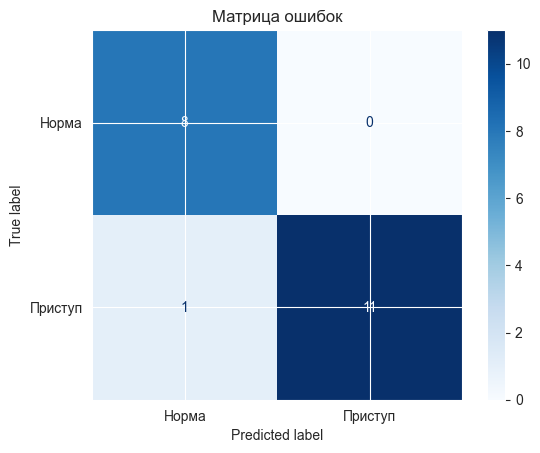


Прогноз для нормального образца: Норма, уверенность: 99.62%
Прогноз для образца приступа: Эпилептический приступ, уверенность: 100.00%


In [50]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import os

# Загрузка обученной модели
model = tf.keras.models.load_model("eeg_best_model.h5")
print("Модель загружена")

IMG_SIZE = (64, 64)
test_ds = tf.keras.utils.image_dataset_from_directory(
    SAVE_DIR, validation_split=0.2, subset="validation",
    seed=42, image_size=IMG_SIZE, batch_size=8, label_mode="binary"
)
test_ds = test_ds.map(lambda x, y: (x / 255.0, y))

# Оценка качества
loss, accuracy = model.evaluate(test_ds, verbose=1)
print(f"Потери: {loss:.4f}")
print(f"Точность: {accuracy:.4f}")

y_true = []
y_pred = []
for x_batch, y_batch in test_ds:
    pred_prob = model.predict(x_batch, verbose=0)
    y_true.extend(y_batch.numpy().flatten())
    y_pred.extend((pred_prob > 0.5).astype(int).flatten())

print("\nОтчёт по классификации:")
print(classification_report(y_true, y_pred, target_names=["Норма", "Эпилептический приступ"], digits=3))

# Матрица ошибок
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=["Норма", "Приступ"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Матрица ошибок")
plt.show()

# Демонстрация предсказания
def predict_one_image(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_arr = tf.keras.preprocessing.image.img_to_array(img)
    img_arr = np.expand_dims(img_arr, axis=0) / 255.0
    pred = model.predict(img_arr, verbose=0)[0][0]
    if pred > 0.5:
        return "Эпилептический приступ", float(pred)
    else:
        return "Норма", float(1 - pred)

test_norm = os.path.join(NORMAL_DIR, "normal_0.png")
test_seiz = os.path.join(SEIZURE_DIR, "seizure_0.png")
res1, conf1 = predict_one_image(test_norm)
res2, conf2 = predict_one_image(test_seiz)

print(f"\nПрогноз для нормального образца: {res1}, уверенность: {conf1:.2%}")
print(f"Прогноз для образца приступа: {res2}, уверенность: {conf2:.2%}")